In [1]:
import warnings
warnings.filterwarnings('ignore')   # keep the notebook output readable

import glob
import logging
import os

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray  # noqa: F401, activates the .rio accessor
import xarray as xr
from shapely.geometry import Point

import GRSl2bgen

logging.getLogger().setLevel(logging.WARNING)
opj = os.path.join

# lighter figures for the documentation
%config InlineBackend.figure_formats = ['jpeg']
plt.rcParams.update({'figure.dpi': 72, 'font.size': 12, 'axes.titlesize': 12})

print(f'GRSl2bgen {GRSl2bgen.__version__}')

GRSl2bgen 1.0.0


In [2]:
rootdir = '/data/satellite/Sentinel-2/L2A/'
dcdir = '/data/satellite/Sentinel-2/datacube/'
insitu_file = '/DATA/projet/bagre/data/MES_Kapore.csv'

tile = '30PYT'
start_date, end_date = '2018-01-01', '2022-12-31'

station_lon, station_lat = -0.7766, 11.663   # Kaporé station
box_size = 2000          # m, side of the datacube box
aoi_radius = 200         # m, radius of the matchup area
max_delay = pd.Timedelta('2D')
min_coverage = 0.5

l2a_cube_path = opj(dcdir, f'{tile}_{start_date}_{end_date}_matchup.nc')
l2b_cube_path = opj(dcdir, f'{tile}_{start_date}_{end_date}_matchup_L2B.nc')

In [3]:
def list_l2a_products(rootdir, tile, pattern='*L2A*'):
    """List the GRS L2A products of a tile into a DataFrame indexed by acquisition time."""
    paths = glob.glob(opj(rootdir, tile, '*', '*', '*', pattern))
    names = pd.Series([os.path.basename(p) for p in paths])
    products = names.str.split('_', expand=True)
    products.columns = ['satellite', 'level', 'time', 'baseline', 'orbit', 'tile', 'processing_time']
    products['time'] = pd.to_datetime(products['time'])
    products['path'] = paths
    return products.set_index('time').sort_index()


if not os.path.exists(l2a_cube_path):
    import grstbx
    box = grstbx.SpatioTemp().wktbox(station_lon, station_lat, width=box_size, height=box_size)
    bbox = gpd.GeoDataFrame(geometry=gpd.GeoSeries.from_wkt([box]), crs=4326)
    files = list_l2a_products(rootdir, tile)[start_date:end_date].path.values
    print(f'{len(files)} L2A products to process')
    dc = grstbx.L2grs(files)
    dc.get_l2a_datacube(subset=bbox)
    dc.datacube.to_netcdf(l2a_cube_path)

l2a = xr.open_dataset(l2a_cube_path, decode_coords='all')
print(f"{l2a.sizes['time']} images from {l2a.time.dt.date.values[0]} to {l2a.time.dt.date.values[-1]}, "
      f"{l2a.sizes['x']} x {l2a.sizes['y']} pixels of {abs(l2a.rio.resolution()[0]):.0f} m, "
      f"{l2a.sizes['wl']} bands")
l2a[['Rrs', 'mask', 'flags']]

158 images from 2018-01-02 to 2022-12-27, 101 x 100 pixels of 20 m, 11 bands


<xarray.Dataset> Size: 155MB
Dimensions:             (time: 158, wl: 11, y: 100, x: 101)
Coordinates:
  * time                (time) datetime64[ns] 1kB 2018-01-02T10:24:21 ... 202...
  * wl                  (wl) int64 88B 443 490 560 665 705 ... 842 865 1610 2190
    central_wavelength  (time, wl) float32 7kB ...
  * y                   (y) float64 800B 1.291e+06 1.291e+06 ... 1.289e+06
  * x                   (x) float64 808B 7.414e+05 7.414e+05 ... 7.434e+05
    band                int64 8B ...
    spatial_ref         int64 8B ...
Data variables:
    Rrs                 (time, wl, y, x) float64 140MB ...
    mask                (time, y, x) uint8 2MB ...
    flags               (time, y, x) int64 13MB ...
Attributes: (12/74)
    long_name:                           CA BLUE GREEN RED VRE_1 VRE_2 VRE_3 ...
    constellation:                       Sentinel-2
    constellation_id:                    S2
    product_path:                        /data/satellite/Sentinel-2/L1C/30PYT...
    product_name:                        S2A_MSIL1C_20180102T102421_N0500_R06...
    product_filename:                    S2A_MSIL1C_20180102T102421_N0500_R06...
    ...                                  ...
    dirdata:                             /data/grs/grsdata
    abs_gas_file:                        /home/harmel/Dropbox/Dropbox/work/gi...
    water_vapor_transmittance_file:      /home/harmel/Dropbox/Dropbox/work/gi...
    metadata_profile:                    datacube
    start_date:                          2018-01-02T10:24:21.000000000
    stop_date:                           2022-12-27T10:24:31.000000000

312 pixels in the disk, 122 valid dates out of 158


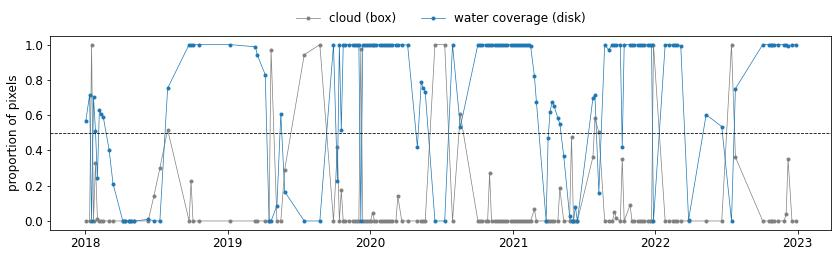

In [4]:
station = gpd.GeoDataFrame(geometry=[Point(station_lon, station_lat)], crs=4326)
aoi = station.to_crs(l2a.rio.crs).buffer(aoi_radius).to_frame('geometry')

# boolean (y, x) map of the matchup disk
disk = xr.ones_like(l2a.sza.isel(time=0)).rio.clip(aoi.geometry.values, drop=False).notnull()
npix = int(disk.sum())
coverage = ((l2a.mask == 0) & disk).sum(['x', 'y']) / npix
valid_dates = coverage.time[coverage >= min_coverage].values
print(f'{npix} pixels in the disk, {len(valid_dates)} valid dates out of {l2a.sizes["time"]}')

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(l2a.time, l2a.flag_cloud_p06, 'o-', ms=3, lw=0.7, color='grey', label='cloud (box)')
ax.plot(coverage.time, coverage, 'o-', ms=3, lw=0.7, color='tab:blue', label='water coverage (disk)')
ax.axhline(min_coverage, color='k', ls='--', lw=0.8)
ax.set_ylabel('proportion of pixels')
ax.legend(ncols=2, loc='lower center', bbox_to_anchor=(0.5, 1.0), frameon=False)
plt.show()

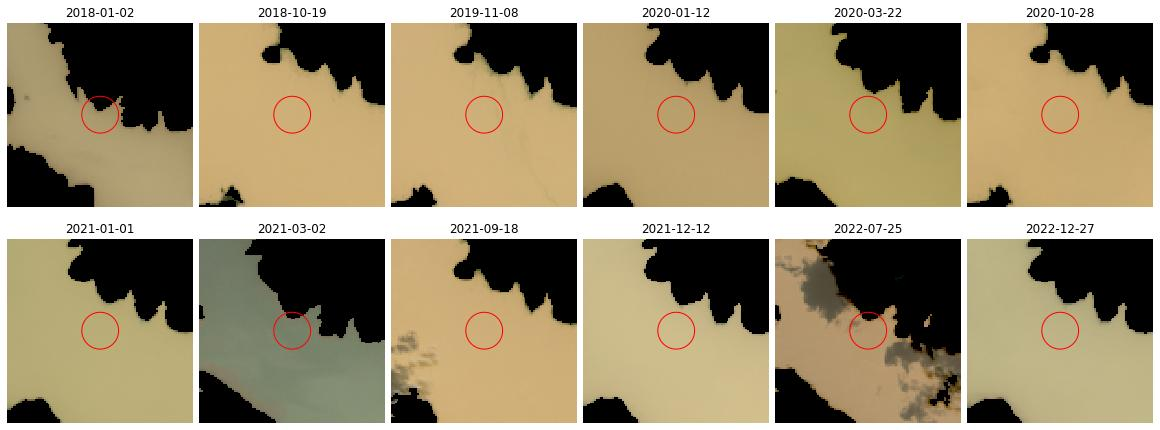

In [5]:
def show_rgb(ds, ax, vmax=0.12, gamma=0.6):
    """True-colour composite from Rrs (665, 560, 490 nm) with a gamma stretch."""
    rgb = ds.Rrs.sel(wl=[665, 560, 490]).fillna(0)
    rgb = (rgb / vmax).clip(0, 1) ** gamma
    rgb.plot.imshow(rgb='wl', ax=ax, add_labels=False)
    aoi.boundary.plot(ax=ax, color='red', lw=1)
    ax.set_aspect('equal')
    ax.set_axis_off()


selection = valid_dates[np.linspace(0, len(valid_dates) - 1, 12).astype(int)]
fig, axs = plt.subplots(2, 6, figsize=(16, 6), constrained_layout=True)
for ax, date in zip(axs.ravel(), selection):
    show_rgb(l2a.sel(time=date), ax)
    ax.set_title(str(pd.Timestamp(date).date()))
plt.show()

In [6]:
def process_image(img):
    """Run the GRSl2bgen chain on one L2A image and add the OWT-blended SPM."""
    proc = GRSl2bgen.Process(img)
    proc.execute()
    spm = GRSl2bgen.Spm(img.where(img.mask == 0))
    spm.process_blended()
    return xr.merge([proc.l2b.l2b_prod, spm.spm_blend, spm.owt_index_spm]).compute()


if not os.path.exists(l2b_cube_path):
    l2b_list = []
    for date in valid_dates:
        img = l2a.sel(time=date).drop_vars('central_wavelength').load()
        img.attrs = dict(img.attrs)   # the L2B product updates the attributes in place
        l2b_list.append(process_image(img))
    l2b = xr.concat(l2b_list, dim='time', coords='minimal', compat='override',
                    combine_attrs='override')
    l2b.attrs = {'processor': f'GRSl2bgen_{GRSl2bgen.__version__}',
                 'source': os.path.basename(l2a_cube_path)}
    l2b.to_netcdf(l2b_cube_path, encoding={v: {'zlib': True, 'complevel': 5} for v in l2b.data_vars})

l2b = xr.open_dataset(l2b_cube_path, decode_coords='all').rio.write_crs(l2a.rio.crs)
l2b

<xarray.Dataset> Size: 159MB
Dimensions:                     (time: 122, Nclasses: 3, y: 100, x: 101)
Coordinates:
  * time                        (time) datetime64[ns] 976B 2018-01-02T10:24:2...
  * Nclasses                    (Nclasses) int64 24B 0 1 2
  * y                           (y) float64 800B 1.291e+06 ... 1.289e+06
  * x                           (x) float64 808B 7.414e+05 ... 7.434e+05
    spatial_ref                 int64 8B 0
    band                        int64 8B ...
Data variables: (12/19)
    owt_dist_Spyrakos2018       (time, Nclasses, y, x) float32 15MB ...
    owt_index_Spyrakos2018      (time, Nclasses, y, x) float32 15MB ...
    owt_dist_Bi2024             (time, y, x) float32 5MB ...
    owt_index_Bi2024            (time, y, x) float32 5MB ...
    owt_dist_Ta2025             (time, y, x) float32 5MB ...
    owt_index_Ta2025            (time, y, x) float32 5MB ...
    ...                          ...
    acdom_B15                   (time, y, x) float64 10MB ...
    Kd_par                      (time, y, x) float64 10MB ...
    flags                       (time, y, x) int64 10MB ...
    mask                        (time, y, x) uint8 1MB ...
    SPM_OWTblend                (time, y, x) float32 5MB ...
    owt_index_Cordeiro2022_SPM  (time, y, x) float32 5MB ...
Attributes:
    processor:  GRSl2bgen_1.0.0
    source:     30PYT_2018-01-01_2022-12-31_matchup.nc

226 samples from 2018-03-13 to 2021-12-31
42 matchups, per year: {2018: 3, 2019: 7, 2020: 13, 2021: 19}


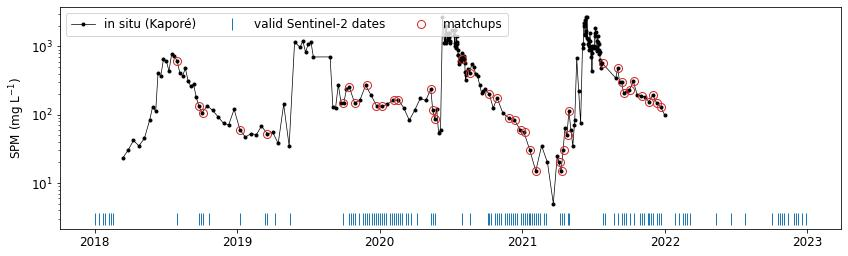

In [7]:
insitu = pd.read_csv(insitu_file, index_col=0, date_format='%d/%m/%Y')
insitu.index.name = 'time'
print(f'{len(insitu)} samples from {insitu.index[0].date()} to {insitu.index[-1].date()}')

sat_times = pd.DataFrame({'sat_time': valid_dates}, index=pd.DatetimeIndex(valid_dates).normalize())
insitu_times = pd.DataFrame({'insitu_time': insitu.index}, index=insitu.index)
matchups = pd.merge_asof(sat_times, insitu_times, left_index=True, right_index=True,
                         tolerance=max_delay, direction='nearest').dropna()
matchups['delay_days'] = (matchups.index - matchups.insitu_time).dt.days
matchups['spm'] = insitu.spm.loc[matchups.insitu_time].values
matchups = matchups.set_index('sat_time')
spm_obs = matchups.spm.values
print(f'{len(matchups)} matchups, per year:', matchups.index.year.value_counts().sort_index().to_dict())

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(insitu.index, insitu.spm, 'o-', ms=3, lw=0.7, color='k', label='in situ (Kaporé)')
ax.plot(valid_dates, np.full(len(valid_dates), 3), '|', ms=12, color='tab:blue', label='valid Sentinel-2 dates')
ax.plot(matchups.index, matchups.spm, 'o', ms=8, mfc='none', color='tab:red', label='matchups')
ax.set_yscale('log')
ax.set_ylabel(r'SPM (mg L$^{-1}$)')
ax.legend(ncols=3)
plt.show()

In [8]:
l2b_disk = l2b.where(disk)
l2b_mu = l2b_disk.sel(time=matchups.index.values)


def disk_mode(da):
    """Most frequent class of the disk for each date."""
    return (da.to_dataframe(name='k').k.dropna().groupby(level='time')
            .agg(lambda s: int(s.mode()[0])).reindex(da.time.values))


owt_mu = pd.DataFrame({
    'Spyrakos2018': disk_mode(l2b_mu.owt_index_Spyrakos2018.isel(Nclasses=0)),
    'Bi2024': disk_mode(l2b_mu.owt_index_Bi2024),
    'Ta2025': disk_mode(l2b_mu.owt_index_Ta2025),
    'Cordeiro2022_SPM': disk_mode(l2b_mu.owt_index_Cordeiro2022_SPM),
})
owt_mu['spm'] = spm_obs
owt_mu.head()

,Spyrakos2018,Bi2024,Ta2025,Cordeiro2022_SPM,spm
time,,,,,
2018-07-31 10:24:21,10,9,14,4,614
2018-09-24 10:24:21,10,9,9,4,134
2018-10-04 10:24:21,5,9,9,4,106
2019-01-07 10:24:21,11,9,9,3,60
2019-03-18 10:24:21,5,9,9,3,53


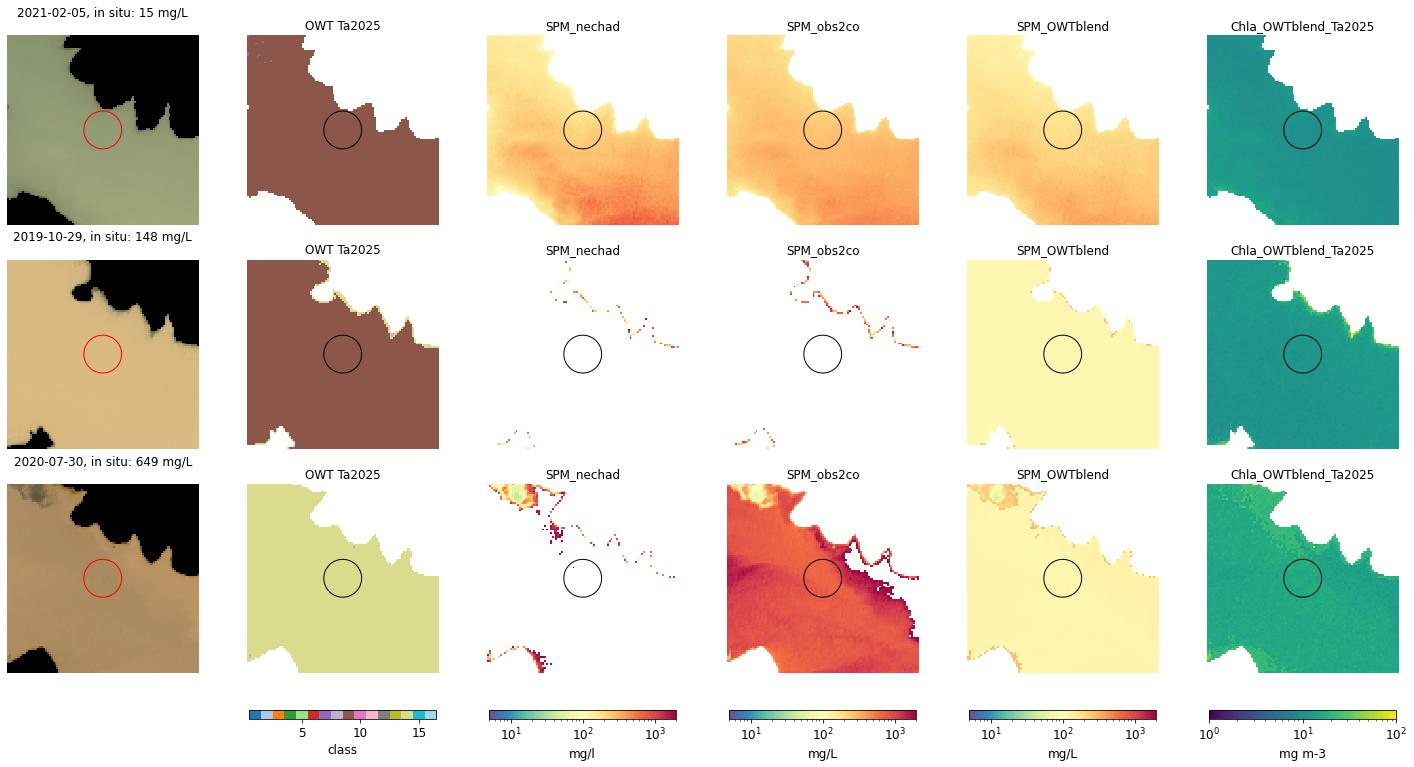

In [9]:
order = np.argsort(spm_obs)
dates = matchups.index[order[[0, len(order) // 2, -1]]]
panels = [
    ('owt_index_Ta2025', dict(cmap=plt.get_cmap('tab20', 16), vmin=0.5, vmax=16.5), 'OWT Ta2025'),
    ('SPM_nechad', dict(cmap='Spectral_r', norm=mpl.colors.LogNorm(5, 2000)), 'SPM_nechad'),
    ('SPM_obs2co', dict(cmap='Spectral_r', norm=mpl.colors.LogNorm(5, 2000)), 'SPM_obs2co'),
    ('SPM_OWTblend', dict(cmap='Spectral_r', norm=mpl.colors.LogNorm(5, 2000)), 'SPM_OWTblend'),
    ('Chla_OWTblend_Ta2025', dict(cmap='viridis', norm=mpl.colors.LogNorm(1, 100)), 'Chla_OWTblend_Ta2025'),
]
fig, axs = plt.subplots(len(dates), len(panels) + 1, figsize=(20, 10.5), constrained_layout=True)
for row, date in zip(axs, dates):
    show_rgb(l2a.sel(time=date), row[0])
    row[0].set_title(f'{date.date()}, in situ: {matchups.spm[date]:.0f} mg/L')
    for ax, (var, kwargs, title) in zip(row[1:], panels):
        da = l2b[var].sel(time=date)
        im = da.plot.imshow(ax=ax, add_colorbar=False, add_labels=False, **kwargs)
        aoi.boundary.plot(ax=ax, color='k', lw=1)
        ax.set_title(title)
        ax.set_aspect('equal')
        ax.set_axis_off()
        if date == dates[-1]:
            fig.colorbar(im, ax=axs[:, list(row).index(ax)], orientation='horizontal', shrink=0.8,
                         label=l2b[var].attrs.get('units', 'class'))
plt.show()

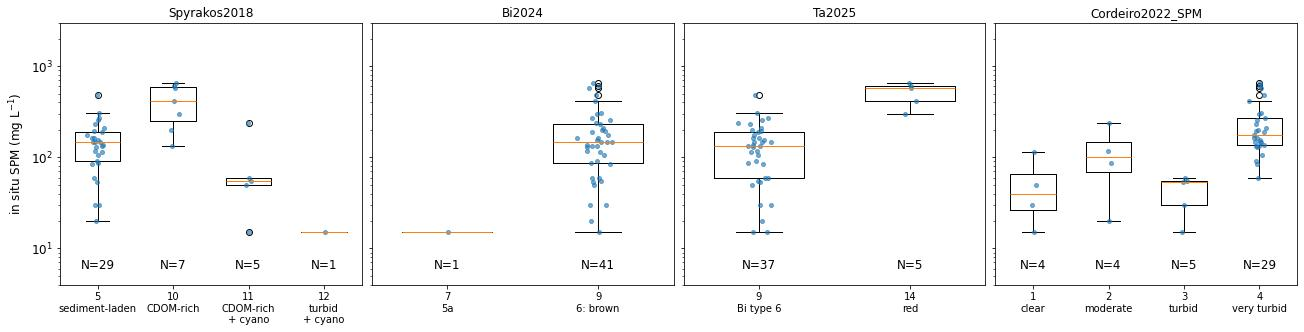

In [10]:
names = {'Spyrakos2018': {5: 'sediment-laden', 10: 'CDOM-rich', 11: 'CDOM-rich\n+ cyano', 12: 'turbid\n+ cyano'},
         'Bi2024': {7: '5a', 9: '6: brown'},
         'Ta2025': {9: 'Bi type 6', 14: 'red'},
         'Cordeiro2022_SPM': {1: 'clear', 2: 'moderate', 3: 'turbid', 4: 'very turbid'}}
fig, axs = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True, constrained_layout=True)
for ax, (db, labels) in zip(axs, names.items()):
    classes = sorted(owt_mu[db].dropna().unique())
    groups = [owt_mu.spm[owt_mu[db] == k] for k in classes]
    ax.boxplot(groups, widths=0.6)
    for i, g in enumerate(groups, start=1):
        ax.plot(np.random.default_rng(0).normal(i, 0.06, len(g)), g, 'o', ms=4, alpha=0.6, color='tab:blue')
        ax.text(i, 6, f'N={len(g)}', ha='center')
    ax.set_xticks(range(1, len(classes) + 1),
                  [f'{int(k)}\n{labels.get(int(k), "")}' for k in classes], fontsize=10)
    ax.set_title(db)
    ax.set_yscale('log')
    ax.set_ylim(4, 3000)
axs[0].set_ylabel(r'in situ SPM (mg L$^{-1}$)')
plt.show()

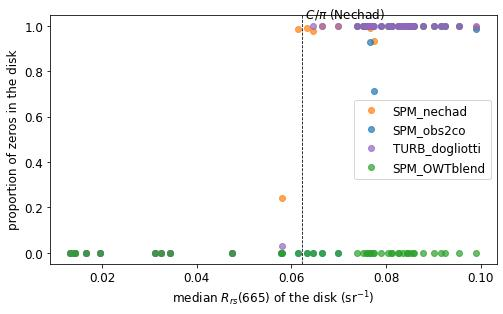

In [11]:
red_mu = l2a.Rrs.sel(wl=665, time=matchups.index.values).where((l2a.mask == 0) & disk).median(['x', 'y'])
spm_vars = ['SPM_nechad', 'SPM_obs2co', 'TURB_dogliotti', 'SPM_OWTblend']
colors = dict(zip(spm_vars, ['tab:orange', 'tab:blue', 'tab:purple', 'tab:green']))

fig, ax = plt.subplots(figsize=(8, 4.5))
for var in spm_vars:
    da = l2b_mu[var]
    zeros = (da == 0).sum(['x', 'y']) / da.notnull().sum(['x', 'y'])
    ax.plot(red_mu, zeros, 'o', color=colors[var], alpha=0.7, label=var)
ax.axvline(0.19563 / np.pi, color='k', ls='--', lw=0.8)
ax.text(0.19563 / np.pi, 1.02, ' $C/\\pi$ (Nechad)', va='bottom')
ax.set_xlabel(r'median $R_{rs}(665)$ of the disk (sr$^{-1}$)')
ax.set_ylabel('proportion of zeros in the disk')
ax.legend(loc='center right')
plt.show()

In [12]:
def disk_median(da, min_valid=0.5):
    """Median of the positive values of the disk; NaN when they are less than `min_valid` of the water pixels."""
    positive = da.where(da > 0)
    frac = positive.count(['x', 'y']) / da.count(['x', 'y'])
    return positive.median(['x', 'y']).where(frac >= min_valid).values


def metrics(estimate, reference):
    """Error statistics of an SPM estimate (N, RMSE, MAPE, bias, median ratio, r of the logs)."""
    estimate, reference = np.asarray(estimate, dtype=float), np.asarray(reference, dtype=float)
    ok = np.isfinite(estimate) & (estimate > 0)
    est, ref = estimate[ok], reference[ok]
    return {'N': int(ok.sum()),
            'RMSE': np.sqrt(np.mean((est - ref) ** 2)),
            'MAPE (%)': 100 * np.mean(np.abs(est - ref) / ref),
            'bias': np.mean(est - ref),
            'median ratio': np.median(est / ref),
            'r (log)': np.corrcoef(np.log(est), np.log(ref))[0, 1]}


estimates = {var: disk_median(l2b_mu[var]) for var in spm_vars}
pd.DataFrame({name: metrics(est, spm_obs) for name, est in estimates.items()}).T.round(2)

,N,RMSE,MAPE (%),bias,median ratio,r (log)
SPM_nechad,11.0,277.00,306.48,88.20,0.78,0.32
SPM_obs2co,16.0,572.49,671.86,298.04,1.67,0.36
TURB_dogliotti,10.0,621.93,1264.90,384.33,3.44,0.39
SPM_OWTblend,42.0,189.81,125.10,-67.44,0.61,0.23


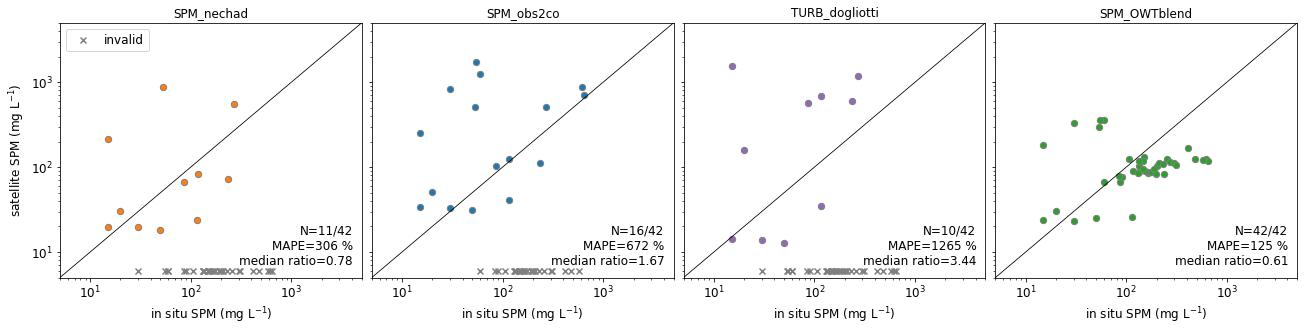

In [13]:
def scatter_matchups(estimates, colors):
    fig, axs = plt.subplots(1, len(estimates), figsize=(4.5 * len(estimates), 4.5), sharex=True, sharey=True,
                            constrained_layout=True)
    for ax, (name, est) in zip(axs, estimates.items()):
        est = np.asarray(est, dtype=float)
        ok = np.isfinite(est) & (est > 0)
        ax.scatter(spm_obs[~ok], np.full((~ok).sum(), 6), marker='x', color='grey', label='invalid')
        ax.scatter(spm_obs[ok], est[ok], color=colors[name], edgecolors='grey', s=40)
        ax.axline((10, 10), (1000, 1000), color='k', lw=0.8)
        st = metrics(est, spm_obs)
        ax.text(0.97, 0.04, f"N={st['N']}/{len(est)}\nMAPE={st['MAPE (%)']:.0f} %\n"
                f"median ratio={st['median ratio']:.2f}", transform=ax.transAxes, ha='right', va='bottom')
        ax.set_title(name)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'in situ SPM (mg L$^{-1}$)')
    axs[0].set_ylabel('satellite SPM (mg L$^{-1}$)')
    axs[0].set_xlim(5, 5000)
    axs[0].set_ylim(5, 5000)
    axs[0].legend(loc='upper left')
    plt.show()


scatter_matchups(estimates, colors)

In [14]:
Rrs_valid = l2a.Rrs.sel(time=valid_dates).where((l2a.mask == 0) & disk).drop_vars('central_wavelength')
Rrs_median = Rrs_valid.median(['x', 'y']).load()
Rrs_mu = Rrs_median.sel(time=matchups.index.values)


def exp_model(coefs, ratio):
    return coefs[0] * np.exp(coefs[1] * ratio)


def fit_exp_model(ratio, spm):
    """Least squares fit of log(SPM) = log(a) + b * ratio; returns (a, b)."""
    b, log_a = np.polyfit(ratio, np.log(spm), 1)
    return np.array([np.exp(log_a), b])


def loo_estimates(ratio, spm):
    """Leave-one-out estimates of the exponential model."""
    return np.array([exp_model(fit_exp_model(np.delete(ratio, i), np.delete(spm, i)), ratio[i])
                     for i in range(len(ratio))])


results, models, loo = [], {}, {}
for wl in [665, 705, 740, 783, 842, 865]:
    ratio = (Rrs_mu.sel(wl=wl) / Rrs_mu.sel(wl=560)).values
    models[wl] = fit_exp_model(ratio, spm_obs)
    loo[wl] = loo_estimates(ratio, spm_obs)
    calib, cv = metrics(exp_model(models[wl], ratio), spm_obs), metrics(loo[wl], spm_obs)
    results.append({'ratio': f'{wl}/560', 'a': models[wl][0], 'b': models[wl][1],
                    'MAPE (%)': calib['MAPE (%)'], 'MAPE LOO (%)': cv['MAPE (%)'],
                    'median ratio LOO': cv['median ratio'], 'r (log) LOO': cv['r (log)']})
results = pd.DataFrame(results).set_index('ratio')
best_wl = int(results['MAPE LOO (%)'].idxmin().split('/')[0])
print(f'best ratio (leave-one-out): {best_wl}/560')
results.round(2)

best ratio (leave-one-out): 705/560


,a,b,MAPE (%),MAPE LOO (%),median ratio LOO,r (log) LOO
ratio,,,,,,
665/560,1.40,3.86,54.50,58.40,0.94,0.70
705/560,1.02,4.16,45.11,48.21,0.99,0.81
740/560,16.39,2.78,46.27,49.69,1.01,0.80
783/560,17.70,2.46,50.85,54.66,0.97,0.78
842/560,22.48,2.66,52.42,56.66,0.92,0.77
865/560,33.26,2.42,65.42,70.49,0.85,0.69


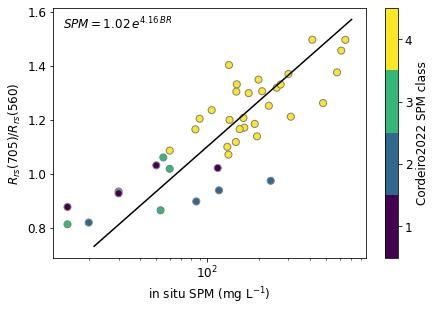

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ratio = Rrs_mu.sel(wl=best_wl) / Rrs_mu.sel(wl=560)
sc = ax.scatter(spm_obs, ratio, c=owt_mu.Cordeiro2022_SPM, cmap=plt.get_cmap('viridis', 4), vmin=0.5, vmax=4.5,
                edgecolors='grey', s=50)
ratio_simu = np.linspace(float(ratio.min()) * 0.9, float(ratio.max()) * 1.05, 200)
a, b = models[best_wl]
ax.plot(exp_model(models[best_wl], ratio_simu), ratio_simu, color='k')
ax.text(0.03, 0.97, f'$SPM = {a:.2f}\\,e^{{{b:.2f}\\,BR}}$', transform=ax.transAxes, va='top')
ax.set_xscale('log')
ax.set_xlabel(r'in situ SPM (mg L$^{-1}$)')
ax.set_ylabel(f'$R_{{rs}}({best_wl})/R_{{rs}}(560)$')
fig.colorbar(sc, ticks=[1, 2, 3, 4], label='Cordeiro2022 SPM class')
plt.show()

,N,RMSE,MAPE (%),bias,median ratio,r (log)
SPM_nechad,11.0,277.00,306.48,88.20,0.78,0.32
SPM_obs2co,16.0,572.49,671.86,298.04,1.67,0.36
TURB_dogliotti,10.0,621.93,1264.90,384.33,3.44,0.39
SPM_OWTblend,42.0,189.81,125.10,-67.44,0.61,0.23
regional 705/560 (LOO),42.0,100.38,48.21,-15.71,0.99,0.81


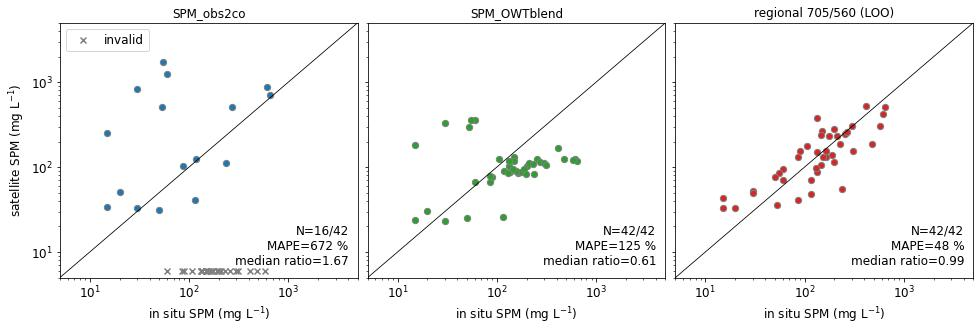

In [16]:
estimates[f'regional {best_wl}/560 (LOO)'] = loo[best_wl]
colors[f'regional {best_wl}/560 (LOO)'] = 'tab:red'
display(pd.DataFrame({name: metrics(est, spm_obs) for name, est in estimates.items()}).T.round(2))
scatter_matchups({k: estimates[k] for k in ['SPM_obs2co', 'SPM_OWTblend', f'regional {best_wl}/560 (LOO)']},
                 colors)

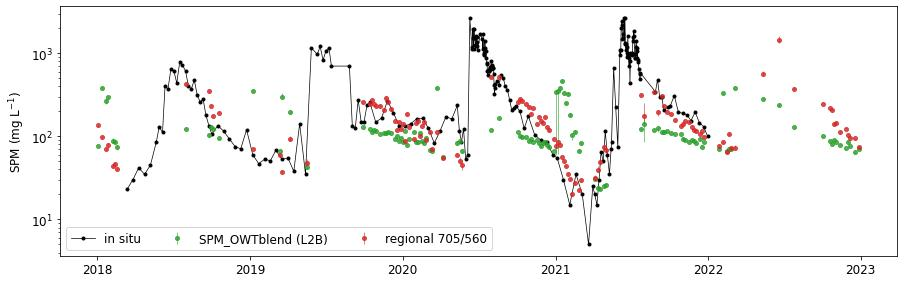

In [17]:
def spm_regional(Rrs, wl=best_wl):
    return exp_model(models[wl], Rrs.sel(wl=wl) / Rrs.sel(wl=560))


series = {
    'SPM_OWTblend (L2B)': (l2b_disk.SPM_OWTblend, 'tab:green'),
    f'regional {best_wl}/560': (spm_regional(Rrs_valid), 'tab:red'),
}
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(insitu.index, insitu.spm, 'o-', ms=3, lw=0.7, color='k', label='in situ')
for name, (da, color) in series.items():
    med = da.median(['x', 'y']).values
    q25, q75 = da.quantile([0.25, 0.75], dim=['x', 'y']).values
    ax.errorbar(da.time.values, med, yerr=[med - q25, q75 - med], fmt='o', ms=4, color=color,
                elinewidth=0.7, alpha=0.8, label=name)
ax.set_yscale('log')
ax.set_ylabel(r'SPM (mg L$^{-1}$)')
ax.legend(ncols=3)
plt.show()

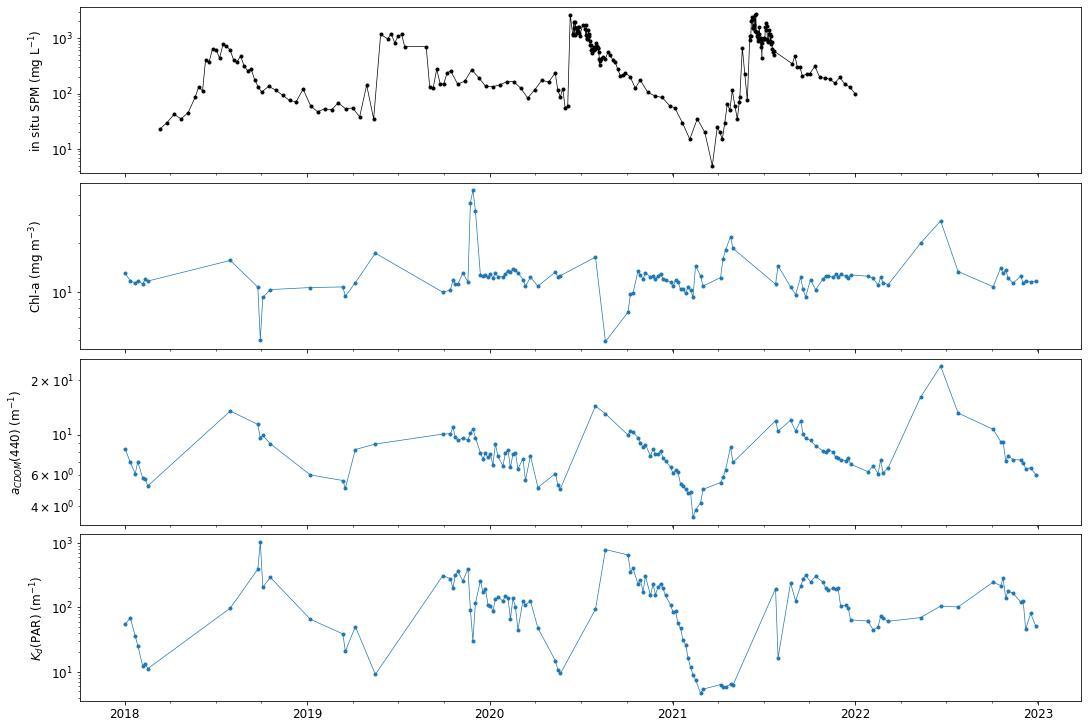

In [18]:
params = [('Chla_OWTblend_Ta2025', r'Chl-a (mg m$^{-3}$)'),
          ('acdom_B15', r'$a_{CDOM}(440)$ (m$^{-1}$)'),
          ('Kd_par', r'$K_d$(PAR) (m$^{-1}$)')]
fig, axs = plt.subplots(len(params) + 1, 1, figsize=(15, 10), sharex=True, constrained_layout=True)
axs[0].plot(insitu.index, insitu.spm, 'o-', ms=3, lw=0.7, color='k')
axs[0].set_ylabel(r'in situ SPM (mg L$^{-1}$)')
axs[0].set_yscale('log')
for ax, (var, label) in zip(axs[1:], params):
    med = l2b_disk[var].median(['x', 'y'])
    ax.plot(med.time, med, 'o-', ms=3, lw=0.7)
    ax.set_yscale('log')
    ax.set_ylabel(label)
for ax in axs:
    ax.minorticks_on()
plt.show()